# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imagenes de ropa como, tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imagenes en 10 categorias. Las imagenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

Importo librerías

In [ ]:
# importa 
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas

In [6]:
# cargo el dataset 
(X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()


La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset.

In [9]:
# nombres de las 10 clases de ropa
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

In [ ]:
# imágenes que hay en train y test
print(f"Imágenes train: {X_train_full.shape[0]}")
print(f"Imágenes test:  {X_test_full.shape[0]}")

# tamaño de cada imagen
print(f"Píxeles por imagen: {X_train_full.shape[1]}x{X_train_full.shape[2]}")

# valores únicos de las etiquetas (clases)
print(f"Clases: {np.unique(y_train_full)}")

Imágenes train: 60000
Imágenes test:  10000
Píxeles por imagen: 28x28
Clases: [0 1 2 3 4 5 6 7 8 9]


## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

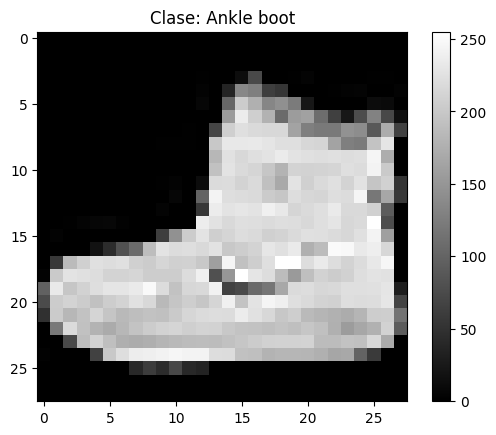

In [ ]:
# muestro la primera imagen del train
plt.imshow(X_train_full[0], cmap='gray')
plt.title(f"Clase: {class_names[y_train_full[0]]}")
plt.colorbar()
plt.show()

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

In [ ]:
# divido entre 255 para convertir los píxeles de 0-255 a 0-1
X_train = X_train_full / 255.0
X_test  = X_test_full / 255.0

Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

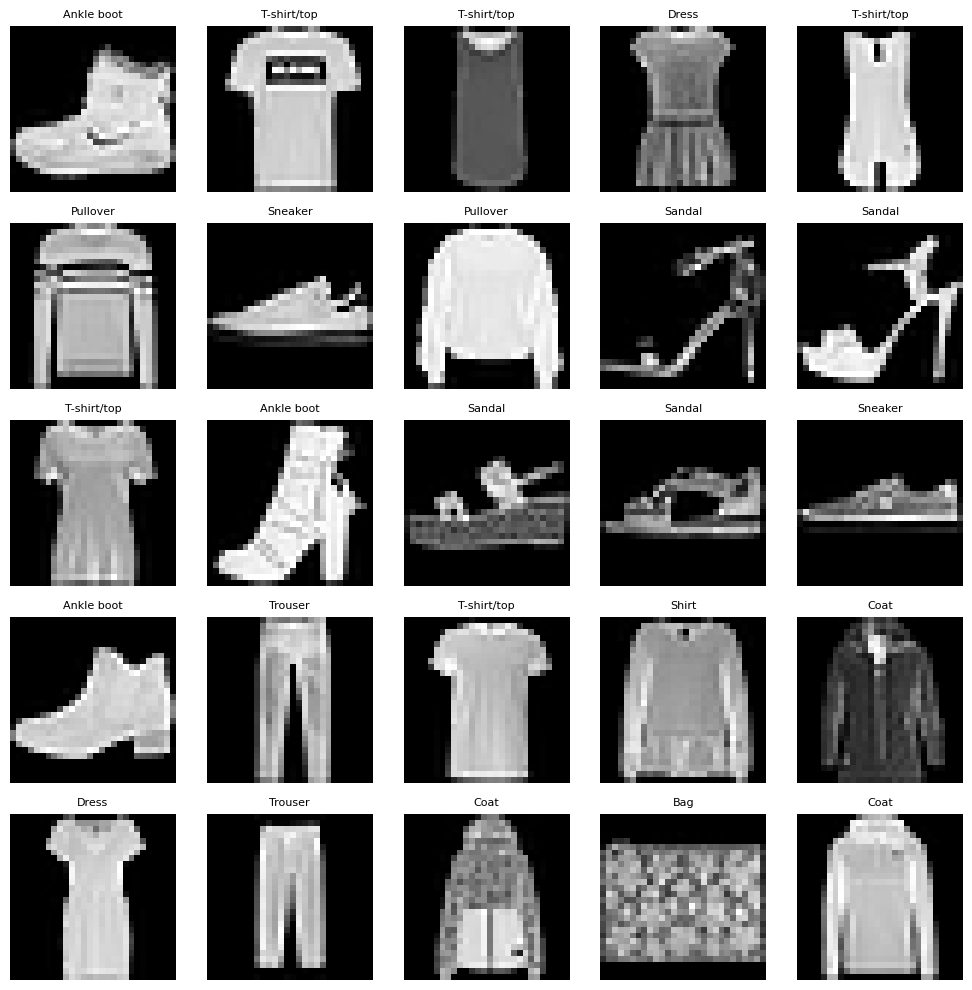

In [ ]:
# creo una cuadrícula de 5x5 para mostrar 25 imágenes
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    # mostramos cada imagen
    plt.imshow(X_train[i], cmap='gray')
    # nombre de la clase como título
    plt.title(class_names[y_train_full[i]], fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

### Configurar las Capas
Construye todas las capas del modelo.

In [37]:
# aplano antes de construir el modelo
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat  = X_test.reshape(-1, 28*28)

# defino el modelo
model = keras.Sequential([
    # capa oculta 1: 64 neuronas, relu descarta valores negativos
    keras.layers.Dense(64, activation='relu', input_shape=(784,)),
    # capa oculta 2: 32 neuronas, sigue aprendiendo patrones
    keras.layers.Dense(32, activation='relu'),
    # capa de salida: 10 neuronas (una por prenda), softmax da probabilidades que suman 1
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

c:\Users\rober\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

In [38]:
# compilo el modelo indicando cómo va a aprender
model.compile(
    # adam ajusta los pesos automáticamente durante el entrenamiento
    optimizer='adam',
    # sparse_categorical_crossentropy mide el error en problemas de múltiples clases
    loss='sparse_categorical_crossentropy',
    # accuracy para ver el porcentaje de aciertos
    metrics=['accuracy']
)

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

In [ ]:
# entreno el modelo con los datos de entrenamiento
history = model.fit(
    # imágenes aplanadas y etiquetas 0-9
    X_train_flat, y_train_full,
    # paso por todos los datos 10 veces
    epochs=10,
    # proceso 32 imágenes a la vez
    batch_size=32,
    # reservo el 20% de los datos para validación
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9754 - loss: 0.0685 - val_accuracy: 0.8777 - val_loss: 0.7557
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9742 - loss: 0.0705 - val_accuracy: 0.8794 - val_loss: 0.8230
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9754 - loss: 0.0671 - val_accuracy: 0.8783 - val_loss: 0.8099
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9745 - loss: 0.0683 - val_accuracy: 0.8788 - val_loss: 0.7979
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9747 - loss: 0.0684 - val_accuracy: 0.8783 - val_loss: 0.8190
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9768 - loss: 0.0623 - val_accuracy: 0.8735 - val_loss: 0.8067
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9754 - loss: 0.0684 - val_accuracy: 0.8830 - val_loss: 0.7955
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9761 - loss: 0.0637 - 

epochs = 20

In [39]:
# entreno con 20 epochs
history = model.fit(
    X_train_flat, y_train_full,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# guardo el modelo
model.save('model_20epochs.h5')

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8120 - loss: 0.5434 - val_accuracy: 0.8400 - val_loss: 0.4461
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8565 - loss: 0.3978 - val_accuracy: 0.8597 - val_loss: 0.3765
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8711 - loss: 0.3542 - val_accuracy: 0.8695 - val_loss: 0.3640
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8782 - loss: 0.3319 - val_accuracy: 0.8626 - val_loss: 0.3855
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8857 - loss: 0.3124 - val_accuracy: 0.8553 - val_loss: 0.3846
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8909 - loss: 0.2990 - val_accuracy: 0.8732 - val_loss: 0.3511
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8941 - loss: 0.2861 - val_accuracy: 0.8718 - val_loss: 0.3527
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8960 - loss: 0.2766 - 

Parece que hay algo de overfitting. Pruebo con más epochs a ver si es verdad.

epochs = 50

In [33]:
# entreno el modelo con 50 epochs para ver el overfitting
history = model.fit(
    X_train_flat, y_train_full,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9762 - loss: 0.0660 - val_accuracy: 0.8780 - val_loss: 0.8278
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9744 - loss: 0.0671 - val_accuracy: 0.8747 - val_loss: 0.8213
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9773 - loss: 0.0602 - val_accuracy: 0.8786 - val_loss: 0.9199
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9759 - loss: 0.0645 - val_accuracy: 0.8791 - val_loss: 0.8824
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9774 - loss: 0.0613 - val_accuracy: 0.8740 - val_loss: 0.9165
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9775 - loss: 0.0613 - val_accuracy: 0.8789 - val_loss: 0.9022
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9761 - loss: 0.0657 - val_accuracy: 0.8764 - val_loss: 0.8848
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9781 - loss: 0.0600 - 

Overfitting clarísimo con 50 epochs. El modelo sigue aprendiendo el train, pero la validación no mejora nada desde el epoch 10.

## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

In [40]:
# cargo el modelo guardado con 20 epochs
model = keras.models.load_model('model_20epochs.h5')

# evalúo con test
loss, accuracy = model.evaluate(X_test_flat, y_test_full)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.8796 - loss: 0.3691
Loss: 0.3691
Accuracy: 87.96%


Con epochs = 20 se acerca al punto óptimo de entrenamiento.

## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

In [42]:
# predigo sobre todas las imágenes de test
predictions = model.predict(X_test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step


El modelo ha predecido la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

In [43]:
# muestro el array de probabilidades de la primera imagen
print(predictions[0])

[3.30748071e-06 1.29412183e-06 8.90929357e-07 1.10139911e-06
 1.63445424e-10 1.04476174e-03 1.09662345e-07 1.79570485e-02
 2.91935237e-07 9.80991244e-01]


*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

In [44]:
# la clase con mayor probabilidad es la predicción
print(f"Clase predicha: {np.argmax(predictions[0])}")
print(f"Clase real:     {y_test_full[0]}")
print(f"Prenda:         {class_names[np.argmax(predictions[0])]}")

Clase predicha: 9
Clase real:     9
Prenda:         Ankle boot


Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

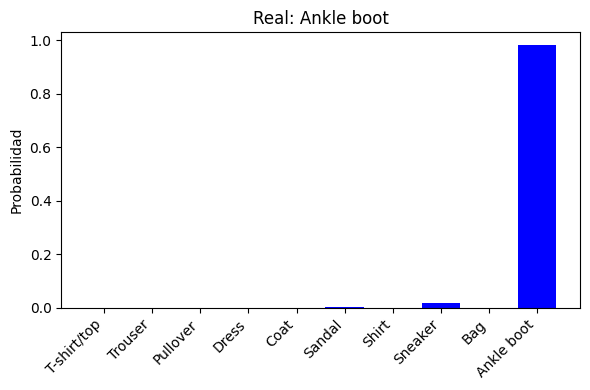

In [45]:
# grafico las probabilidades de las 10 clases para la primera imagen
plt.figure(figsize=(6, 4))

# barra azul si acierta, roja si falla
color = 'blue' if np.argmax(predictions[0]) == y_test_full[0] else 'red'

plt.bar(class_names, predictions[0], color=color)
plt.xticks(rotation=45, ha='right')
plt.title(f"Real: {class_names[y_test_full[0]]}")
plt.ylabel('Probabilidad')
plt.tight_layout()
plt.show()

Miremos la imagen [0], sus predicciones y el array de predicciones. Las etiquetas de predicción correctas estan en azul y las incorrectas están en rojo. El número entrega el porcentaje (sobre 100) para la etiqueta predecida.

Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

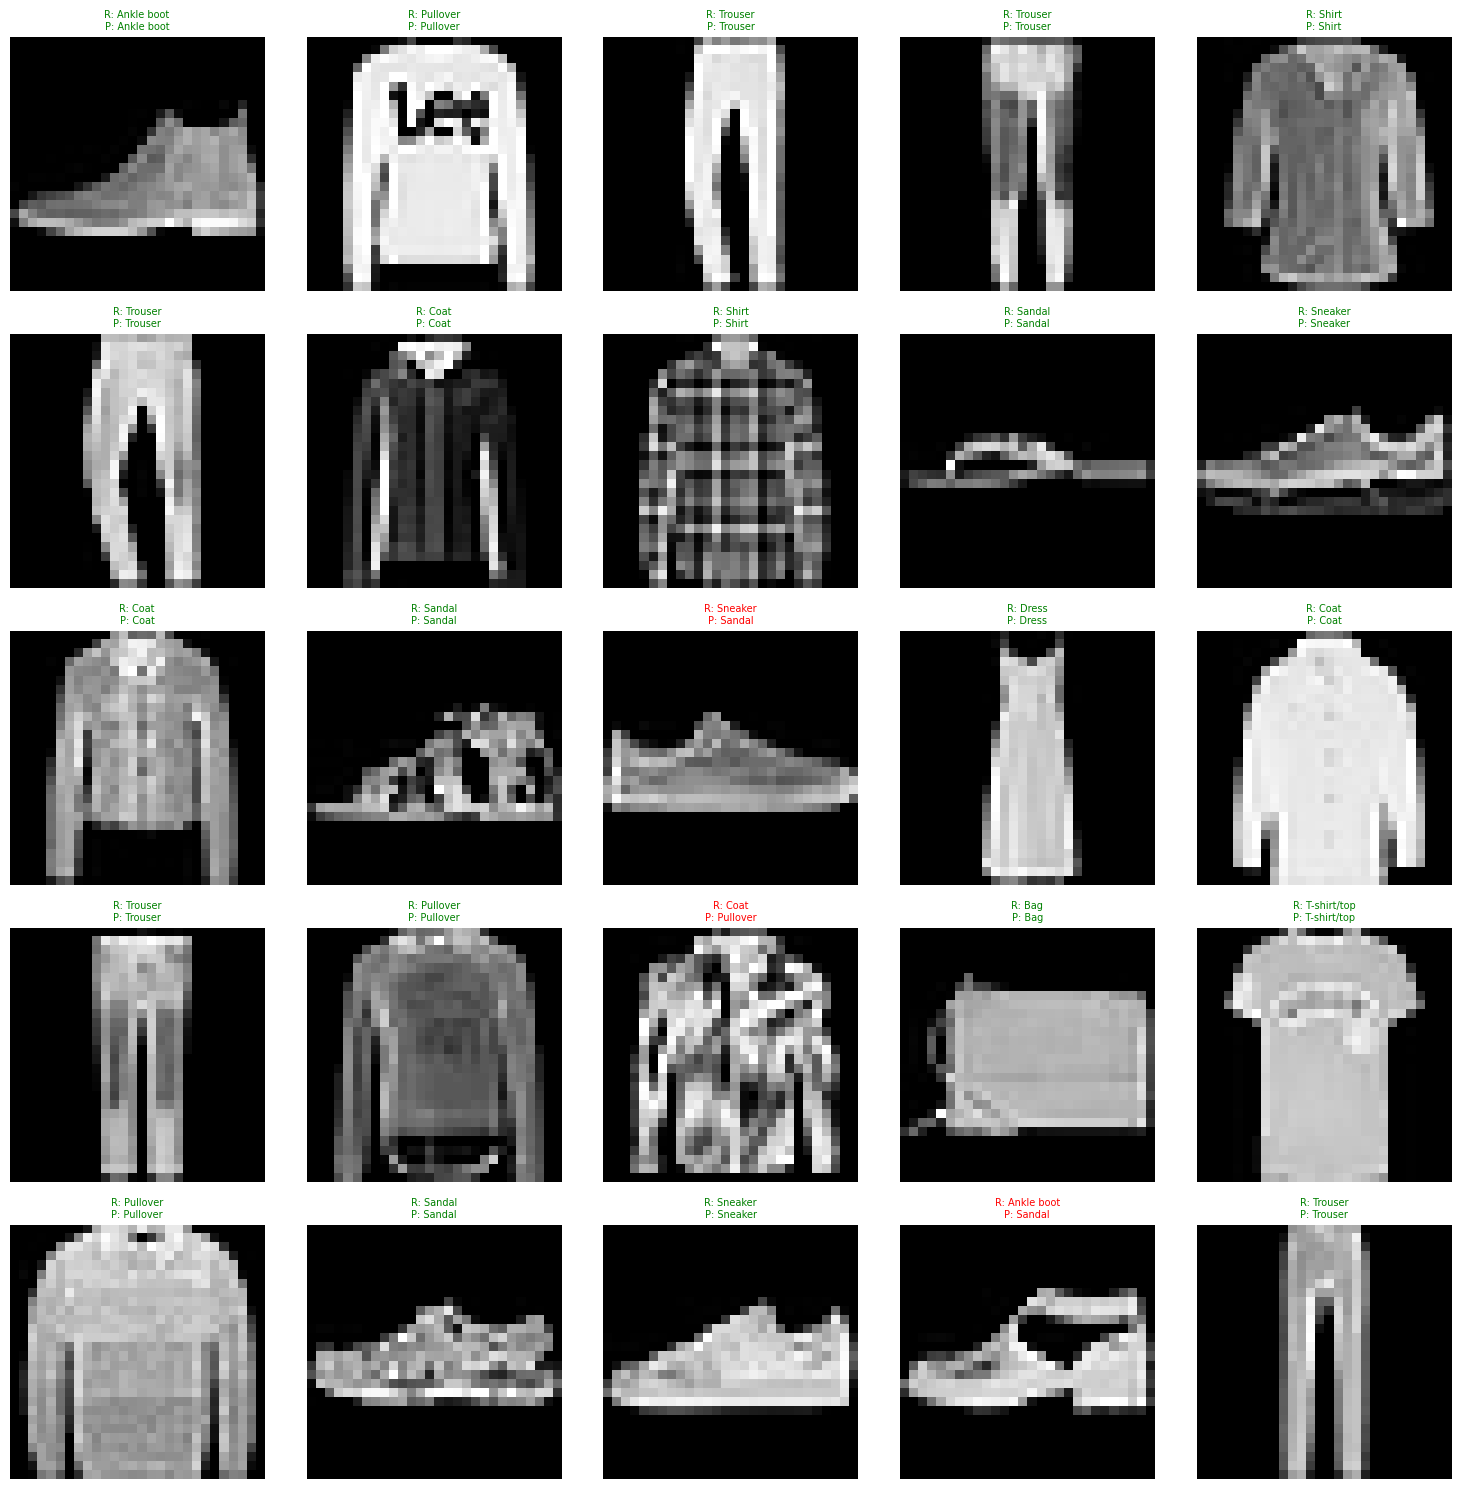

In [46]:
# grafico las primeras 25 imágenes con sus predicciones
plt.figure(figsize=(15, 15))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_test_full[i], cmap='gray')

    # clase predicha y real
    pred_class = np.argmax(predictions[i])
    real_class = y_test_full[i]

    # verde si acierta, rojo si falla
    color = 'green' if pred_class == real_class else 'red'

    title = f"R: {class_names[real_class]}\nP: {class_names[pred_class]}"
    plt.title(title, color=color, fontsize=7)
    plt.axis('off')

plt.tight_layout()
plt.show()

Evalúa tu modelo con una matriz de confusión e interprétala.

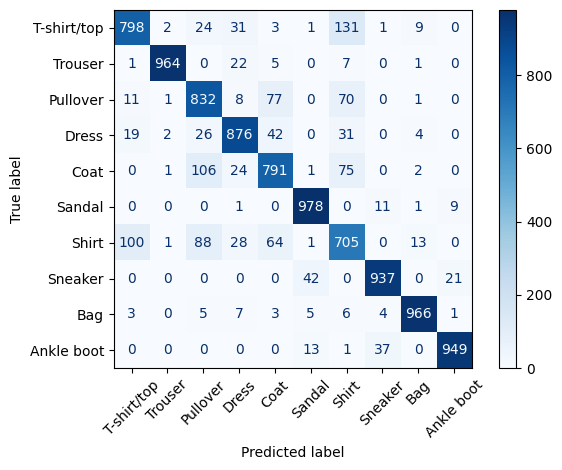

In [48]:
# obtengo la clase predicha para cada imagen
y_pred = np.argmax(predictions, axis=1)

# calculo la matriz de confusión
cm = confusion_matrix(y_test_full, y_pred)

# la muestro con los nombres de las clases
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.tight_layout()
plt.show()

Acierta bien en Trouser (964), Sandal (978), Bag (966) y Ankle boot (949). Esto puede ser porque son prendas con formas muy distintas entre sí.

Se confunde más en Shirt (solo acierta 705), T-shirt/top confundida con Shirt 131 veces y Coat confundida con Pullover 106 veces.

Sin embargo, esto tiene sentido, ya que camiseta, camisa y jersey son prendas muy parecidas en una imagen en blanco y negro de 28x28 píxeles. El modelo falla igual que fallaríamos nosotros.

Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.

In [50]:
# selecciono una única imagen del test
img = X_test_flat[0]

# el modelo espera un grupo de imágenes, con lo que añado una dimensión extra para que la vea como un "grupo de uno"
img_batch = np.expand_dims(img, axis=0)

# predicción
prediction = model.predict(img_batch)

# muestro el resultado
pred_class = np.argmax(prediction)
print(f"Clase predicha: {class_names[pred_class]}")
print(f"Clase real:     {class_names[y_test_full[0]]}")
print(f"Confianza:      {prediction[0][pred_class]:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Clase predicha: Ankle boot
Clase real:     Ankle boot
Confianza:      98.10%


Perfecto. El modelo predice Ankle boot con un 98.10% de confianza y acierta.